Т2. ГЕНЕРАЦИЯ ВЫБОРКИ
Распределение: p(x) = e^(-x), x ≥ 0
Объем выборки: n = 25

Сгенерированная выборка (точнее, её вариационный ряд):
[0.0503, 0.0716, 0.0977, 0.1168, 0.1542, 0.201 , 0.2017, 0.2913, 0.3448,
 0.3738, 0.411 , 0.4248, 0.5513, 0.5781, 0.5818, 0.7803, 0.8893, 0.9488,
 1.0603, 1.0614, 1.1665, 1.3409, 2.0729, 2.3219, 2.583 ]
----------------------------------------------------------------------

a) ХАРАКТЕРИСТИКИ

1. МЕДИАНА (Me)
----------------------------------------
Формула для нечетного n = 25: Me = x_(13)
Результат: Me = 0.5513

2. РАЗМАХ (R)
----------------------------------------
Формула: R = Xmax - Xmin
Xmin = 0.0503, Xmax = 2.5830
Результат: R = 2.5327

3. КОЭФФИЦИЕНТ АСИММЕТРИИ (As)
----------------------------------------
Формула: As = μ₃ / σ³, где μ₃ - центральный момент 3-го порядка
Среднее выборочное (x̄) = 0.7470
Стандартное отклонение (s) = 0.7049
Результат: As = 1.3089

4. МОДА (Mo)
----------------------------------------
Мода - значение, которое встреча

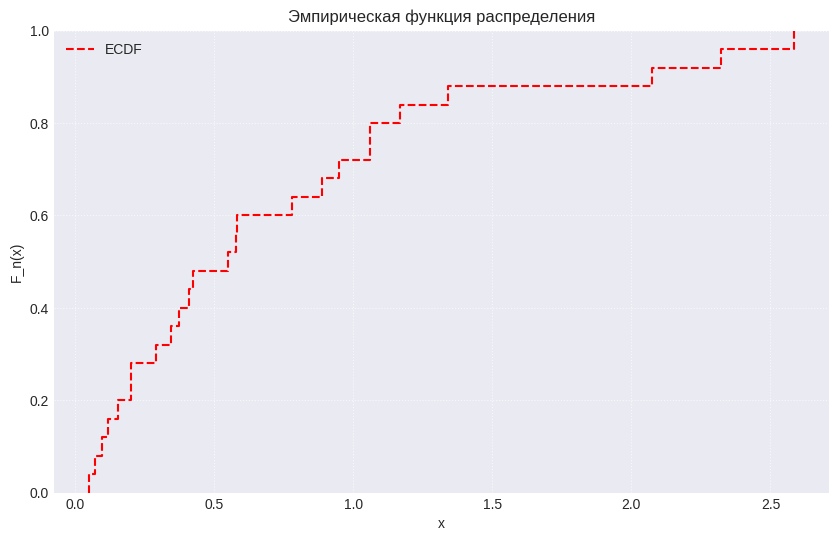


2. ГИСТОГРАММА
----------------------------------------
Количество интервалов: k = 1 + log2(25) = 5


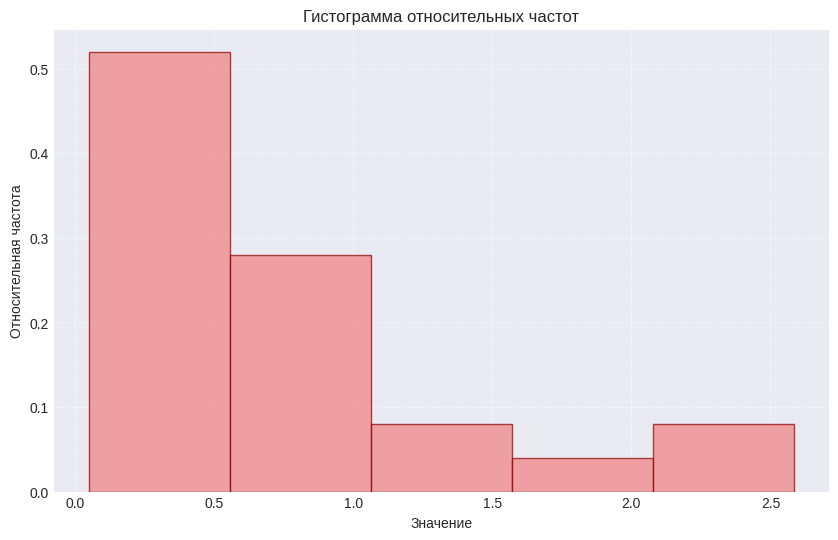


3. ЯЩИК С УСАМИ (BOXPLOT)
----------------------------------------
Элементы boxplot:
  • Медиана (красная линия)
  • Нижний и верхний квартили (границы ящика)
  • Минимум и максимум (усы)
  • Выбросы (точки за пределами усов)


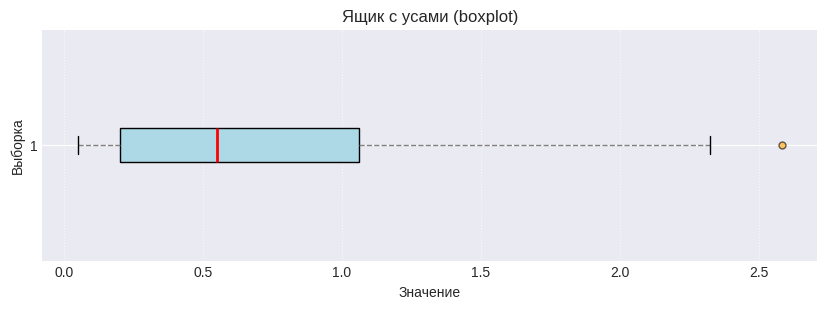

----------------------------------------------------------------------

c) ПЛОТНОСТЬ РАСПРЕДЕЛЕНИЯ СРЕДНЕГО: ЦПТ vs БУТСТРАП

1. ТЕОРИЯ (ЦПТ)
----------------------------------------
По Центральной Предельной Теореме:
  x̄ ~ N(μ, σ²/n), где:
    μ ≈ x̄ (среднее)
    σ ≈ s (стандартное отклонение)

Среднее (x̄) = 0.7470
Стандартное отклонение (s) = 0.7049
Стандартная ошибка среднего (SE = s/√n) = 0.1410

2. БУТСТРАП-ОЦЕНКА
----------------------------------------
Генерируем 1000 бутстрап-выборок объема 25 с возвращением
Среднее бутстрап-распределения: 0.7427
Стандартное отклонение бутстрап-распределения: 0.1386


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 772 (\N{COMBINING MACRON}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


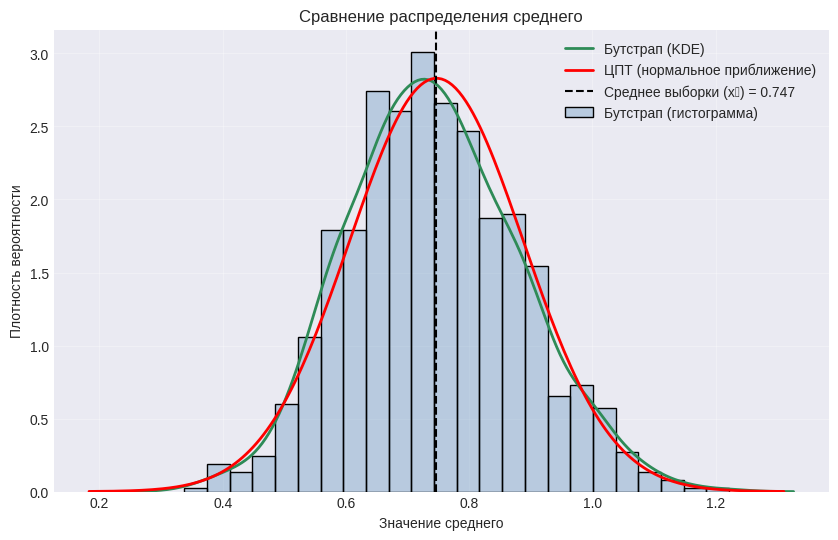

----------------------------------------------------------------------

d) БУТСТРАП-РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТА АСИММЕТРИИ

Генерируем 1000 бутстрап-выборок для оценки распределения асимметрии

Первые 10 бутстраповских значений коэффициента асимметрии:
[1.5578, 1.7194, 1.4188, 1.0144, 0.9252, 1.3335, 1.342 , 0.888 , 0.9613,
 0.8015]

Среднее бутстрап-распределения: 1.2340
Стандартное отклонение: 0.4018


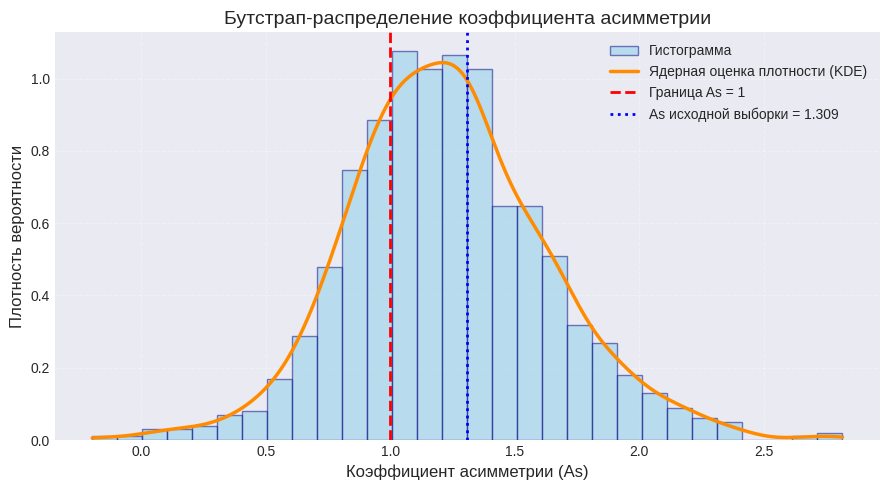


ОЦЕНКА ВЕРОЯТНОСТИ:
----------------------------------------
P(As < 1) ≈ (количество бутстрап-значений < 1) / 1000
P(As < 1) = 0.2790 (27.90%)
----------------------------------------------------------------------

e) РАСПРЕДЕЛЕНИЕ МЕДИАНЫ: ТЕОРЕТИЧЕСКОЕ vs БУТСТРАП

1. ТЕОРЕТИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ МЕДИАНЫ
----------------------------------------
Генерируем 1000 выборок объема 25 из исходного распределения
Среднее теоретического распределения медианы: 0.7055
Стандартное отклонение: 0.2013

2. БУТСТРАП-ОЦЕНКА РАСПРЕДЕЛЕНИЯ МЕДИАНЫ
----------------------------------------
Генерируем 1000 бутстрап-выборок из исходной выборки
Среднее бутстрап-распределения: 0.5405
Стандартное отклонение: 0.1596


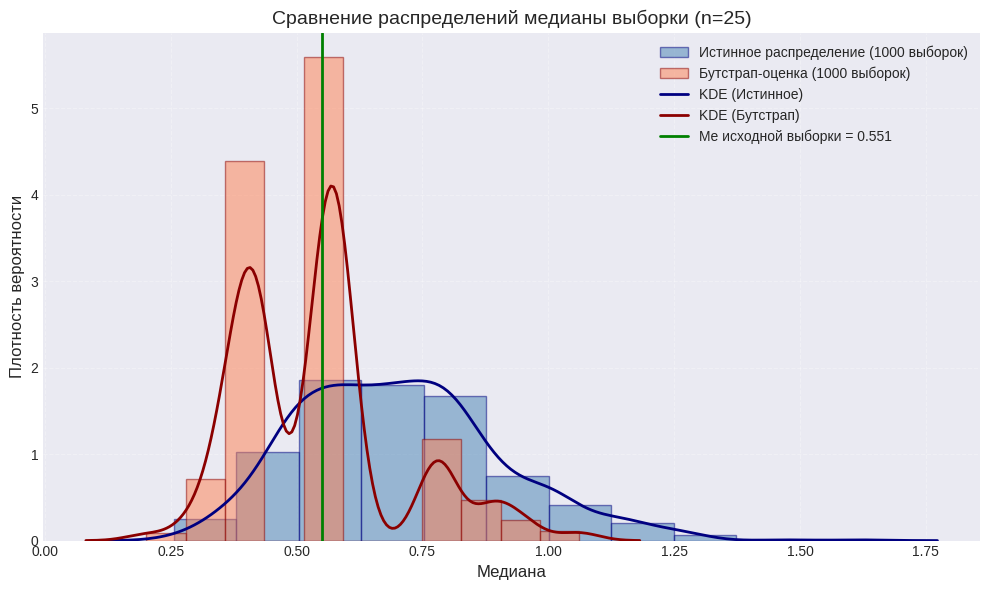


КОНЕЦ (всё)


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import math
from collections import Counter
np.random.seed(228)

# ============================================================
# Т2. Случайная величина имеет экспоненциальный закон распределения (блаблабла). Сгененрируйте выборку объема n=25
# ============================================================
print("="*70)
print("Т2. ГЕНЕРАЦИЯ ВЫБОРКИ")
print("="*70)
print("Распределение: p(x) = e^(-x), x ≥ 0")
n = 25

sample = np.random.exponential(scale=1, size=n)
print(f"Объем выборки: n = {n}")
print("\nСгенерированная выборка (точнее, её вариационный ряд):")
print(np.array2string(np.sort(sample), precision=4, separator=', '))
print("-"*70)


# ============================================================
# Пункт a) Определить по выборке моду(можно...а зачем), медиану, размах, оценку коэффициента асимметрии
# ============================================================
print("\n" + "="*70)
print("a) ХАРАКТЕРИСТИКИ")
print("="*70)

# 1. Медиана (Me) - значение, которое в середине........
# Формула: Me = x_{(n+1)/2} при нечетном n (!)
print("\n1. МЕДИАНА (Me)")
print("-"*40)
print(f"Формула для нечетного n = {n}: Me = x_({(n+1)//2})")
median_sample = np.median(sample)
print(f"Результат: Me = {median_sample:.4f}")

# 2. Размах (R) - разность между максимальным и минимальным значениями
# Формула: R = x_max - x_min
print("\n2. РАЗМАХ (R)")
print("-"*40)
print("Формула: R = Xmax - Xmin")
x_min = np.min(sample)
x_max = np.max(sample)
range_sample = x_max - x_min
print(f"Xmin = {x_min:.4f}, Xmax = {x_max:.4f}")
print(f"Результат: R = {range_sample:.4f}")

# 3. Коэффициент асимметрии (As) - характеристика скошенности распределения
# Формула: As = (1/n) * Σ((x_i - x̄)^3) / s^3, где s - стандартное отклонение
print("\n3. КОЭФФИЦИЕНТ АСИММЕТРИИ (As)")
print("-"*40)
print("Формула: As = μ₃ / σ³, где μ₃ - центральный момент 3-го порядка")
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)  # ddof=1 для несмещенной оценки
print(f"Среднее выборочное (x̄) = {sample_mean:.4f}")
print(f"Стандартное отклонение (s) = {sample_std:.4f}")
skew_sample = stats.skew(sample)
print(f"Результат: As = {skew_sample:.4f}")

# 4. Мода (Mo) - наиболее часто встречающееся значение (и все же зачем... она не показательна для такого распределения)
print("\n4. МОДА (Mo)")
print("-"*40)
print("Мода - значение, которое встречается в выборке наиболее часто")

value_counts = Counter(sample)
max_count = max(value_counts.values())

if max_count > 1:
    modes = [val for val, count in value_counts.items() if count == max_count]

    if len(modes) == 1:
        print(f"В выборке есть повторяющееся значение.")
        print(f"Значение {modes[0]:.4f} встречается {max_count} раз(а)")
        print(f"Результат: Mo = {modes[0]:.4f}")
    else:
        print(f"В выборке несколько значений с одинаковой максимальной частотой.")
        modes_str = ', '.join([f"{m:.4f}" for m in modes])
        print(f"Значения {modes_str} встречаются по {max_count} раз(а)")
        print(f"Результат: Мультимодальная выборка, моды: {modes_str}")
else:
    print("Все значения в выборке уникальны (встречаются по 1 разу).")
    print("Результат: Моды нет")

print("\n" + "-"*70)


# ============================================================
# Пункт b) Построить эмпирическую функцию распределения, гистограмму и boxplot
# ============================================================
print("\n" + "="*70)
print("b) ГРАФИЧЕСКОЕ ПРЕДСТАВЛЕНИЕ ДАННЫХ")
print("="*70)

# 1. Эмпирическая функция распределения
print("\n1. ЭМПИРИЧЕСКАЯ ФУНКЦИЯ РАСПРЕДЕЛЕНИЯ")
print("-"*40)
print("F_n(x) = (количество элементов выборки ≤ x) / n")
fig, ax = plt.subplots(figsize=(10, 6))
ax.ecdf(sample, label='ECDF', linestyle='--', color='red')
ax.set_title('Эмпирическая функция распределения')
ax.set_xlabel('x')
ax.set_ylabel('F_n(x)')
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()
plt.show()

# 2. Гистограмма
print("\n2. ГИСТОГРАММА")
print("-"*40)
bins = int(1 + math.log2(n))
print(f"Количество интервалов: k = 1 + log2({n}) = {bins}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(sample, bins=bins,
        weights=np.ones_like(sample) / n,
        color='lightcoral', edgecolor='darkred', alpha=0.7, rwidth=1.0)
ax.set_title('Гистограмма относительных частот')
ax.set_xlabel('Значение')
ax.set_ylabel('Относительная частота')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 3. Ящик с усами (boxplot)
print("\n3. ЯЩИК С УСАМИ (BOXPLOT)")
print("-"*40)
print("Элементы boxplot:")
print("  • Медиана (красная линия)")
print("  • Нижний и верхний квартили (границы ящика)")
print("  • Минимум и максимум (усы)")
print("  • Выбросы (точки за пределами усов)")

fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(sample, vert=False, patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='gray', linestyle='--'),
           capprops=dict(color='black'),
           flierprops=dict(marker='o', markerfacecolor='orange', markersize=5, alpha=0.6))
ax.set_title('Ящик с усами (boxplot)')
ax.set_xlabel('Значение')
ax.set_ylabel('Выборка')
ax.grid(True, axis='x', linestyle=':', alpha=0.7)
plt.show()
print("-"*70)


# ============================================================
# Пункт c) Сравнить оценку плотности распределения среднего арифметического с помощью ЦПТ и бутстраповскую оценку
# ============================================================
print("\n" + "="*70)
print("c) ПЛОТНОСТЬ РАСПРЕДЕЛЕНИЯ СРЕДНЕГО: ЦПТ vs БУТСТРАП")
print("="*70)

# Выборочное среднее и стандартная ошибка
print("\n1. ТЕОРИЯ (ЦПТ)")
print("-"*40)
print("По Центральной Предельной Теореме:")
print("  x̄ ~ N(μ, σ²/n), где:")
print("    μ ≈ x̄ (среднее)")
print("    σ ≈ s (стандартное отклонение)")

sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)
std_error = sample_std / np.sqrt(n)

print(f"\nСреднее (x̄) = {sample_mean:.4f}")
print(f"Стандартное отклонение (s) = {sample_std:.4f}")
print(f"Стандартная ошибка среднего (SE = s/√n) = {std_error:.4f}")

# Бутстрап
print("\n2. БУТСТРАП-ОЦЕНКА")
print("-"*40)
print(f"Генерируем {1000} бутстрап-выборок объема {n} с возвращением")
n_bootstrap = 1000
rng = np.random.default_rng(seed=42)
bootstrap_means = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    boot_sample = rng.choice(sample, size=n, replace=True)
    bootstrap_means[i] = np.mean(boot_sample)

boot_mean = np.mean(bootstrap_means)
boot_std = np.std(bootstrap_means)
print(f"Среднее бутстрап-распределения: {boot_mean:.4f}")
print(f"Стандартное отклонение бутстрап-распределения: {boot_std:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(bootstrap_means, stat='density', alpha=0.3,
             label='Бутстрап (гистограмма)', color='steelblue', ax=ax)
sns.kdeplot(bootstrap_means, label='Бутстрап (KDE)',
            color='seagreen', linewidth=2, ax=ax)

x = np.linspace(sample_mean - 4*std_error, sample_mean + 4*std_error, 200)
normal_pdf = stats.norm.pdf(x, loc=sample_mean, scale=std_error)
ax.plot(x, normal_pdf, 'r-', linewidth=2, label='ЦПТ (нормальное приближение)')

ax.axvline(sample_mean, color='black', linestyle='--',
           label=f'Среднее выборки (x̄) = {sample_mean:.3f}')

ax.set_title('Сравнение распределения среднего')
ax.set_xlabel('Значение среднего')
ax.set_ylabel('Плотность вероятности')
ax.legend()
ax.grid(alpha=0.3)

plt.show()
print("-"*70)


# ============================================================
# Пункт d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятность того, что коэффициент асимметрии будет меньше 1
# ============================================================
print("\n" + "="*70)
print("d) БУТСТРАП-РАСПРЕДЕЛЕНИЕ КОЭФФИЦИЕНТА АСИММЕТРИИ")
print("="*70)

print(f"\nГенерируем {1000} бутстрап-выборок для оценки распределения асимметрии")
B = 1000
rng_skew = np.random.default_rng(seed=123)
boot_skew = np.zeros(B)

for i in range(B):
    boot_sample = rng_skew.choice(sample, size=n, replace=True)
    boot_skew[i] = stats.skew(boot_sample)

print("\nПервые 10 бутстраповских значений коэффициента асимметрии:")
print(np.array2string(boot_skew[:10], precision=4, separator=', '))

boot_skew_mean = np.mean(boot_skew)
boot_skew_std = np.std(boot_skew)
print(f"\nСреднее бутстрап-распределения: {boot_skew_mean:.4f}")
print(f"Стандартное отклонение: {boot_skew_std:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(boot_skew, bins=30, density=True, alpha=0.5,
        color='skyblue', edgecolor='navy', label='Гистограмма')

kde = stats.gaussian_kde(boot_skew)
x_grid = np.linspace(boot_skew.min(), boot_skew.max(), 200)
ax.plot(x_grid, kde(x_grid), color='darkorange', lw=2.5, label='Ядерная оценка плотности (KDE)')

ax.axvline(x=1, color='red', linestyle='--', linewidth=2, label='Граница As = 1')
ax.axvline(x=skew_sample, color='blue', linestyle=':', linewidth=2,
           label=f'As исходной выборки = {skew_sample:.3f}')

ax.set_title('Бутстрап-распределение коэффициента асимметрии', fontsize=14)
ax.set_xlabel('Коэффициент асимметрии (As)', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.legend()
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# Оценка вероятности
prob_less_1 = np.mean(boot_skew < 1)
print(f"\nОЦЕНКА ВЕРОЯТНОСТИ:")
print("-"*40)
print(f"P(As < 1) ≈ (количество бутстрап-значений < 1) / {B}")
print(f"P(As < 1) = {prob_less_1:.4f} ({prob_less_1*100:.2f}%)")
print("-"*70)


# ============================================================
# Пункт e) Сравнить плотность распределения медианы выборки м бутстраповской оценкой этой плотности
# ============================================================
print("\n" + "="*70)
print("e) РАСПРЕДЕЛЕНИЕ МЕДИАНЫ: ТЕОРЕТИЧЕСКОЕ vs БУТСТРАП")
print("="*70)

# Теоретическое распределение медианы
print("\n1. ТЕОРЕТИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ МЕДИАНЫ")
print("-"*40)
print(f"Генерируем {1000} выборок объема {n} из исходного распределения")
B_true = 1000
rng_true = np.random.default_rng(seed=456)
true_medians = np.zeros(B_true)

for i in range(B_true):
    x_true = rng_true.exponential(scale=1, size=n)
    true_medians[i] = np.median(x_true)

print(f"Среднее теоретического распределения медианы: {np.mean(true_medians):.4f}")
print(f"Стандартное отклонение: {np.std(true_medians):.4f}")

# Бутстрап-распределение медианы
print("\n2. БУТСТРАП-ОЦЕНКА РАСПРЕДЕЛЕНИЯ МЕДИАНЫ")
print("-"*40)
print(f"Генерируем {1000} бутстрап-выборок из исходной выборки")
R_boot = 1000
rng_median_boot = np.random.default_rng(seed=789)
bootstrap_medians = np.zeros(R_boot)

for i in range(R_boot):
    boot_sample = rng_median_boot.choice(sample, size=n, replace=True)
    bootstrap_medians[i] = np.median(boot_sample)

print(f"Среднее бутстрап-распределения: {np.mean(bootstrap_medians):.4f}")
print(f"Стандартное отклонение: {np.std(bootstrap_medians):.4f}")

fig, ax = plt.subplots(figsize=(10, 6))

# Гистограммы с нормировкой на плотность
ax.hist(true_medians, bins=11, density=True,
        alpha=0.5, color='steelblue', edgecolor='navy',
        label='Истинное распределение (1000 выборок)')
ax.hist(bootstrap_medians, bins=11, density=True,
        alpha=0.5, color='coral', edgecolor='darkred',
        label='Бутстрап-оценка (1000 выборок)')


sns.kdeplot(true_medians, color='navy', linewidth=2,
            label='KDE (Истинное)', ax=ax)
sns.kdeplot(bootstrap_medians, color='darkred', linewidth=2,
            label='KDE (Бутстрап)', ax=ax)

ax.axvline(x=median_sample, color='green', linestyle='-', linewidth=2,
           label=f'Me исходной выборки = {median_sample:.3f}')

ax.set_xlabel('Медиана', fontsize=12)
ax.set_ylabel('Плотность вероятности', fontsize=12)
ax.set_title('Сравнение распределений медианы выборки (n=25)', fontsize=14)
ax.legend()
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("КОНЕЦ (всё)")
print("="*70)